In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
sns.set_theme()

import utils_DevTrad


'''
main_dir = "/home/garo/Desktop/Lavoro_Studio/DevTrad/code/Stylized_Facts/"
data_path = "/home/garo/Desktop/Lavoro_Studio/DevTrad/data/"
'''

main_dir = "/home/user/code_and_output/"
data_path = "/home/user/data/"

# Base font size for ticks
base_fontsize = 8
# Calculate font sizes for labels and title
label_fontsize = base_fontsize * 1.16
title_fontsize = base_fontsize * 1.16
# Update Matplotlib rcParams
plt.rcParams.update({
    "font.size": 2*base_fontsize,           # Set default font size for text
    "xtick.labelsize": 2*base_fontsize,      # Set font size for x-tick labels
    "ytick.labelsize": 2*base_fontsize,      # Set font size for y-tick labels
    "axes.labelsize": 2*label_fontsize,      # Set font size for x and y labels
    "axes.titlesize": 2*title_fontsize       # Set font size for the title
})

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

print(f"These are the pools considered (Total = {len(Pools)})")
for pool in Name_Pools.values():
    print(pool.replace("\\", ""))

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


These are the pools considered (Total = 24)
USDC-WETH 0.01%
USDC-WETH 0.05%
USDC-WETH 0.3%
WETH-USDT 0.01%
WETH-USDT 0.05%
WETH-USDT 0.3%
WBTC-USDC 0.05%
WBTC-USDC 0.3%
WBTC-USDT 0.05%
WBTC-USDT 0.3%
WBTC-WETH 0.01%
WBTC-WETH 0.05%
WBTC-WETH 0.3%
LINK-WETH 0.3%
MNT-WETH 0.3%
UNI-WETH 0.3%
USDC-USDT 0.01%
USDC-USDT 0.05%
DAI-USDC 0.01%
DAI-USDT 0.01%
USDe-USDT 0.01%
WETH-weETH 0.01%
wstETH-WETH 0.01%
WBTC-LBTC 0.05%


/home/garo/miniconda3/envs/DevTrad/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Summary Dataset Statistics

In [ ]:

# Summary of the dataset used

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

print("Pool & Start & # Swaps & S/B & S/T & # Mint & # Burn & Wait B & # Wallets")

total, n_total, n_echo_same, n_echo_diff, echo_same, echo_diff = dict(), dict(), dict(), dict(), dict(), dict()
for pool_name in Pools:
    curr_folder = f'{pool_name.upper()}/'
    dataset_path = f'{data_path}{pool_name}.pickle'
    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)
        
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    
    to_print = Name_Pools[pool_name] + ' & '
    to_print += str(df.index[0])[:10] + ' & '
    to_print += f'{len(df_swap):,.0f} & '
    to_print += f'{len(df_swap)/len(df_swap.block_number.unique()):.2f} & '
    temp_ticks = df_swap.tick.diff().values[1:]
    to_print += f'{len(df_swap)/(temp_ticks!=0).sum():.2f} & '
    to_print += f'{len(df[ df.Event=="Mint" ]):,.0f} & '
    to_print += f'{len(df[ df.Event=="Burn" ]):,.0f} & '
    to_print += f'{(df.block_number.iloc[-1]-df.block_number.iloc[0])/(len(df.block_number.unique())-1):.2f} & '
    to_print += f'{len(df_swap.wallet.unique()):,.0f} \\\\'

    print(to_print)
    

Pool & Start & # Swaps & S/B & S/T & # Mint & # Burn & Wait B & # Wallets
USDC-WETH 0.01\% & 2023-01-01 & 861,917 & 1.44 & 1.28 & 3,009 & 3,243 & 8.69 & 189,594 \\
USDC-WETH 0.05\% & 2023-01-01 & 4,115,698 & 1.56 & 2.97 & 75,449 & 83,461 & 1.95 & 824,769 \\
USDC-WETH 0.3\% & 2023-01-01 & 238,996 & 1.10 & 1.61 & 9,339 & 17,629 & 21.93 & 75,447 \\
WETH-USDT 0.01\% & 2023-02-22 & 1,917,101 & 1.61 & 1.43 & 6,970 & 7,441 & 4.05 & 404,850 \\
WETH-USDT 0.05\% & 2023-01-01 & 2,826,625 & 1.37 & 2.20 & 15,641 & 17,134 & 2.53 & 640,902 \\
WETH-USDT 0.3\% & 2023-01-01 & 420,329 & 1.10 & 2.46 & 13,757 & 16,524 & 13.00 & 149,109 \\
WBTC-USDC 0.05\% & 2023-01-01 & 205,205 & 1.14 & 1.09 & 2,812 & 3,058 & 28.61 & 36,743 \\
WBTC-USDC 0.3\% & 2023-01-01 & 91,080 & 1.07 & 1.09 & 5,236 & 6,404 & 56.02 & 14,035 \\
WBTC-USDT 0.05\% & 2023-03-31 & 66,454 & 1.12 & 1.08 & 586 & 603 & 76.41 & 17,784 \\
WBTC-USDT 0.3\% & 2023-01-01 & 96,804 & 1.06 & 1.13 & 3,068 & 3,529 & 54.75 & 17,791 \\
WBTC-WETH 0.01\% & 2023

In [ ]:

# Summary of the Price and Liquidity time series
from scipy.stats import kurtosis

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

print("Pool & Q0.1 S & Q0.5 S & Q0.9 S & std(r) & Kurt & RV & RV^* & L min & Q0.5 L & L max")

total, n_total, n_echo_same, n_echo_diff, echo_same, echo_diff = dict(), dict(), dict(), dict(), dict(), dict()
for pool_name in Pools:
    curr_folder = f'{pool_name.upper()}/'
    dataset_path = f'{data_path}{pool_name}.pickle'
    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)

    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    
    to_print = Name_Pools[pool_name] + ' & '

    df_swap_cleaned = df_swap[(df_swap.price!=0) & (~np.isinf(df_swap.price))]
    price = df_swap.price
    liq = df_swap.liquidity
    liq = liq[(price!=0) & (~np.isinf(price))]
    price = price[(price!=0) & (~np.isinf(price))]
    to_print += f'{np.quantile(price, 0.1):.5g} & '# if not pool_name.startswith('wbtc_usd') else f'{np.quantile(to_print, 0.25):.4g}'
    to_print += f'{np.quantile(price, 0.5):.5g} & '
    to_print += f'{np.quantile(price, 0.9):.5g} & '

    log_ret = np.log(price).diff().values[1:]
    to_print += f'{100*np.std(log_ret):.2f} & '# if not pool_name.startswith('wbtc_usd') else f'{np.quantile(to_print, 0.25):.4g}'
    to_print += f'{(kurtosis(log_ret)+3)/1_000:.1f} & '

    n_years = (price.index[-1] - price.index[0]).days / 365.25
    rv = np.log(price.resample('10min').last()).ffill().diff().values[1:]
    rv = np.sum(rv**2) / n_years
    to_print += f'{rv:.4f} & '

    liq = df_swap.liquidity.unique()
    price_res = price.resample('10min').last().ffill()
    liq_res = df_swap.liquidity.resample('10min').last().ffill()
    price_filtered = np.where(liq_res > np.quantile(liq, 0.05), price_res, np.nan)
    rv = np.diff((np.log(price_filtered)))
    rv = np.sum(rv[~np.isnan(rv)]**2) / n_years
    to_print += f'{rv:.4f} & '

    to_print += f'{np.log10(np.min(liq)):.1f} & '# if not pool_name.startswith('wbtc_usd') else f'{np.quantile(to_print, 0.25):.4g}'
    to_print += f'{np.log10(np.quantile(liq, 0.5)):.1f} & '# if not pool_name.startswith('wbtc_usd') else f'{np.quantile(to_print, 0.25):.4g}'
    to_print += f'{np.log10(np.max(liq)):.1f} \\\\'
    print(to_print)


    

Pool & Q0.1 S & Q0.5 S & Q0.9 S & std(r) & Kurt & RV & RV^* & L min & Q0.5 L & L max
USDC-WETH 0.01\% & 1595.7 & 2545.6 & 3489.4 & 4.46 & 53.9 & 0.5594 & 0.1295 & -0.2 & 5.7 & 10.3 \\
USDC-WETH 0.05\% & 1599.2 & 2326 & 3544.6 & 0.06 & 2.2 & 0.3006 & 0.2564 & 5.8 & 7.3 & 9.6 \\
USDC-WETH 0.3\% & 1617.8 & 2432 & 3555.3 & 0.12 & 1.1 & 0.2208 & 0.1866 & 5.8 & 6.9 & 8.8 \\
WETH-USDT 0.01\% & 2302.1 & 2747.3 & 3623.4 & 2.05 & 69.0 & 0.5926 & 0.1818 & 0.9 & 6.0 & 10.1 \\
WETH-USDT 0.05\% & 1623.1 & 2247.8 & 3554.3 & 0.17 & 156.6 & 0.3037 & 0.2629 & 3.5 & 6.7 & 9.2 \\
WETH-USDT 0.3\% & 1654.6 & 2518.2 & 3614.5 & 0.09 & 0.9 & 0.2284 & 0.1844 & 6.0 & 6.7 & 8.6 \\
WBTC-USDC 0.05\% & 26266 & 54441 & 80225 & 5.19 & 19.5 & 0.2363 & 0.2090 & 5.7 & 10.0 & 13.6 \\
WBTC-USDC 0.3\% & 25685 & 57795 & 90956 & 0.18 & 0.2 & 0.1616 & 0.1323 & 9.5 & 10.9 & 13.0 \\
WBTC-USDT 0.05\% & 29299 & 72238 & 98477 & 3.43 & 0.8 & 0.3049 & 0.0718 & -inf & 10.3 & 13.3 \\
WBTC-USDT 0.3\% & 26784 & 61377 & 94456 & 0.21 & 1.6

### JIT Percentage of Fees

Given a swap that is attacked by a JIT, what is the percentage of the fee, paid by the Liquidity Taker, that is earned by the attacker? The percentage earned by non-JIT Liquidity Providers is 1 - JIT percentage.

In [32]:

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Medians, Q25s, Q75s = dict(), dict(), dict()
for pool_name in Pools:
    curr_folder = f'{pool_name.upper()}/'
    dataset_path = f'{data_path}{pool_name}.pickle'
    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)
        
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()
    with open(curr_folder+pool_name + '_jit.pickle', 'rb') as f:
        jit_flag = pickle.load(f)
    df["JIT_flag"] = jit_flag
    with open(curr_folder+pool_name + '_sandwich.pickle', 'rb') as f:
        sandwich_state = pickle.load(f)
    df["sandwich_state"] = sandwich_state

    mint_target = df[ df.Event=='Mint' ]
    mint_target = mint_target[ mint_target.JIT_flag==1 ]

    burn_target = df[ df.Event=='Burn' ]
    burn_target = burn_target[ burn_target.JIT_flag==1 ]

    swap_target = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    swap_target = swap_target[ swap_target.JIT_flag==1 ]

    Fee_pct = list()
    Fee_pct_pure = list()
    for temp_mint, temp_burn in zip(mint_target.iterrows(), burn_target.iterrows()):
        block = temp_mint[1].block_number
        L_jit = temp_mint[1].amount
        start_idx = temp_mint[1].log_index
        end_idx = temp_burn[1].log_index
        up_tick = temp_mint[1].tick_upper
        low_tick = temp_mint[1].tick_lower
        mix_bool = temp_mint[1].sandwich_state == 'Not'

        temp_swap = swap_target[
            (swap_target.block_number==block) & (swap_target.log_index>start_idx) & (swap_target.log_index<end_idx)]
        assert len(temp_swap), 'Swaps not found!!!'

        for swap in temp_swap.iterrows():
            Fee_pct.append(L_jit / swap[1].liquidity)
            if mix_bool:
                Fee_pct_pure.append(L_jit / swap[1].liquidity)
    
    Medians[pool_name] = np.median(Fee_pct) if len(Fee_pct) > 0 else np.nan
    Q25s[pool_name] = np.quantile(Fee_pct, 0.25) if len(Fee_pct) > 0 else np.nan
    Q75s[pool_name] = np.quantile(Fee_pct, 0.75) if len(Fee_pct) > 0 else np.nan

    print(f'{pool_name} num JIT: {len(mint_target)}   q0.25: {Q25s[pool_name]:.3f}   median: {Medians[pool_name]:.3f}   q0.75: {Q75s[pool_name]:.3f}')

usdc_weth_001 num JIT: 1400   q0.25: 0.995   median: 0.999   q0.75: 1.000
usdc_weth_005 num JIT: 34711   q0.25: 0.949   median: 0.973   q0.75: 0.984
usdc_weth_03 num JIT: 1917   q0.25: 0.792   median: 0.932   q0.75: 0.965
weth_usdt_001 num JIT: 3671   q0.25: 0.995   median: 0.999   q0.75: 0.999
weth_usdt_005 num JIT: 8837   q0.25: 0.934   median: 0.976   q0.75: 0.989
weth_usdt_03 num JIT: 3823   q0.25: 0.783   median: 0.889   q0.75: 0.951
wbtc_usdc_005 num JIT: 1330   q0.25: 0.903   median: 0.964   q0.75: 0.990
wbtc_usdc_03 num JIT: 1390   q0.25: 0.899   median: 0.947   q0.75: 0.969
wbtc_usdt_005 num JIT: 332   q0.25: 0.952   median: 0.981   q0.75: 0.995
wbtc_usdt_03 num JIT: 1286   q0.25: 0.866   median: 0.935   q0.75: 0.965
wbtc_weth_001 num JIT: 703   q0.25: 0.991   median: 0.997   q0.75: 1.000
wbtc_weth_005 num JIT: 4518   q0.25: 0.860   median: 0.953   q0.75: 0.983
wbtc_weth_03 num JIT: 621   q0.25: 0.591   median: 0.780   q0.75: 0.896
link_weth_03 num JIT: 4954   q0.25: 0.591   m

### Returns Leptokurtosis - Large Lags

Study Returns Leptokurtosis - Table 6

In [34]:

from scipy.stats import kurtosis, kurtosistest
from sklearn.linear_model import LinearRegression

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001', 'usdc_usdt_001', 'usdc_usdt_005',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

if 'kurtosis.pickle' in os.listdir(f'{main_dir}'):
    with open(f'{main_dir}kurtosis.pickle', 'rb') as f:
        P_Dicts, P_Dicts_Block, To_Print_Swap, To_Print_Block = pickle.load(f)
else:
    P_Dicts = dict()
    P_Dicts_Block = dict()
    To_Print_Swap = dict()
    To_Print_Block = dict()
    for pool_name in tqdm(Pools, desc="Iterating over the pool"):

        curr_folder = f'{pool_name.upper()}/'
        dataset_path = f'{data_path}{pool_name}.pickle'

        with open(dataset_path, 'rb') as f:
            df = pickle.load(f)
        
        df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
        df = df.drop_duplicates()
        df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
        df_swap = df_swap.drop_duplicates()

        Ns = np.unique(list(range(1, 200)) + [int(k) for k in np.logspace(2.302, 5, 1_000)])
        Ns = Ns[ Ns < len(df_swap)/20 ]
        Ks = list()
        Pvals = list()
        for n_swaps in Ns:
            block_ret = np.log(df_swap.price.values)
            block_ret = block_ret[::n_swaps]
            block_ret = block_ret[1:] - block_ret[:-1]
            Ks.append( 3+kurtosis(block_ret) )
            Pvals.append( kurtosistest(block_ret)[1] )

        freq1D = len(df_swap) // len(pd.date_range(df_swap.index[0], df_swap.index[-1], freq='1D'))
        
        start_l, end_l = 15, len(Ks)
        X_temp = np.array(Ks[start_l:end_l])
        mdl_p = LinearRegression(fit_intercept=True)
        mdl_p.fit(np.log(Ns[start_l:end_l]).reshape(-1, 1), np.log(X_temp))
        x_pdf_I = np.linspace(start_l, Ns[-1], 5_000)
        P_Dicts[pool_name] = -mdl_p.coef_[0]
        r2 = mdl_p.score(np.log(Ns[start_l:end_l]).reshape(-1, 1), np.log(X_temp))
        if r2 >= 0.9:
            To_Print_Swap[pool_name] = f"\\texttt{{{Name_Pools[pool_name]}}} & \\textbf{{{mdl_p.intercept_:.2f}}} & \\textbf{{{-mdl_p.coef_[0]:.2f}}} & \\textbf{{{r2:.2f}}} & \\textbf{{{Ns[np.argmax(np.array(Pvals)>0.01)]/freq1D :.2f}}} & \\textbf{{{Ns[np.argmax(np.array(Pvals)>0.05)]/freq1D :.2f}}}"
        elif r2 >= 0.75:
            To_Print_Swap[pool_name] = f"\\texttt{{{Name_Pools[pool_name]}}} & \\underline{{{mdl_p.intercept_:.2f}}} & \\underline{{{-mdl_p.coef_[0]:.2f}}} & \\underline{{{r2:.2f}}} & \\underline{{{Ns[np.argmax(np.array(Pvals)>0.01)]/freq1D :.2f}}} & \\underline{{{Ns[np.argmax(np.array(Pvals)>0.05)]/freq1D :.2f}}}"
        else:
            To_Print_Swap[pool_name] = f"\\texttt{{{Name_Pools[pool_name]}}} & {mdl_p.intercept_:.2f} & {-mdl_p.coef_[0]:.2f} & {r2:.2f} & {Ns[np.argmax(np.array(Pvals)>0.01)]/freq1D :.2f} & {Ns[np.argmax(np.array(Pvals)>0.05)]/freq1D :.2f}"

        Ns = np.unique(list(range(1, 200)) + [int(k) for k in np.logspace(2.302, 5, 1_000)])
        Ns = Ns[ Ns < len(df_swap)/20 ]
        Ks = list()
        Pvals = list()
        for n_swaps in Ns:
            block_ret = np.log(df_swap.groupby("block_number").price.last().values)
            block_ret = block_ret[::n_swaps]
            block_ret = block_ret[1:] - block_ret[:-1]
            Ks.append( 3+kurtosis(block_ret) )
            Pvals.append( kurtosistest(block_ret)[1] )

        freq1D = len(df_swap) // len(pd.date_range(df_swap.index[0], df_swap.index[-1], freq='1D'))
        
        start_l, end_l = 15, len(Ks)
        X_temp = np.array(Ks[start_l:end_l])
        mdl_p = LinearRegression(fit_intercept=True)
        mdl_p.fit(np.log(Ns[start_l:end_l]).reshape(-1, 1), np.log(X_temp))
        x_pdf_I = np.linspace(start_l, Ns[-1], 5_000)
        P_Dicts_Block[pool_name] = -mdl_p.coef_[0]
        r2 = mdl_p.score(np.log(Ns[start_l:end_l]).reshape(-1, 1), np.log(X_temp))
        if r2 >= 0.9:
            To_Print_Block[pool_name] = f"\\texttt{{{Name_Pools[pool_name]}}} & \\textbf{{{mdl_p.intercept_:.2f}}} & \\textbf{{{-mdl_p.coef_[0]:.2f}}} & \\textbf{{{r2:.2f}}} & \\textbf{{{Ns[np.argmax(np.array(Pvals)>0.01)]/freq1D :.2f}}} & \\textbf{{{Ns[np.argmax(np.array(Pvals)>0.05)]/freq1D :.2f}}}"
        elif r2 >= 0.75:
            To_Print_Block[pool_name] = f"\\texttt{{{Name_Pools[pool_name]}}} & \\underline{{{mdl_p.intercept_:.2f}}} & \\underline{{{-mdl_p.coef_[0]:.2f}}} & \\underline{{{r2:.2f}}} & \\underline{{{Ns[np.argmax(np.array(Pvals)>0.01)]/freq1D :.2f}}} & \\underline{{{Ns[np.argmax(np.array(Pvals)>0.05)]/freq1D :.2f}}}"
        else:
            To_Print_Block[pool_name] = f"\\texttt{{{Name_Pools[pool_name]}}} & {mdl_p.intercept_:.2f} & {-mdl_p.coef_[0]:.2f} & {r2:.2f} & {Ns[np.argmax(np.array(Pvals)>0.01)]/freq1D :.2f} & {Ns[np.argmax(np.array(Pvals)>0.05)]/freq1D :.2f}"

    with open(f'{main_dir}kurtosis.pickle', 'wb') as f:
        pickle.dump([P_Dicts, P_Dicts_Block, To_Print_Swap, To_Print_Block], f)


Iterating over the pool: 100%|██████████| 24/24 [17:00<00:00, 42.52s/it]  


In [35]:

#------------------------- TABLE
for pool1, pool2 in zip(Pools[:len(Pools)//2], Pools[len(Pools)//2:]):
    print(To_Print_Swap[pool1] + " & " + To_Print_Swap[pool2] + "\\\\")
    print(" & " + " & ".join(To_Print_Block[pool1].split(" & ")[1:]) + " &  & " + " & ".join(To_Print_Block[pool2].split(" & ")[1:]) + "\\\\")


\texttt{USDC-WETH 0.01\%} & \underline{9.65} & \underline{0.77} & \underline{0.76} & \underline{10.05} & \underline{16.22} & \texttt{WBTC-WETH 0.3\%} & 3.26 & 0.26 & 0.66 & 1.80 & 2.83\\
 & \underline{7.58} & \underline{0.57} & \underline{0.87} & \underline{9.27} & \underline{9.27} &  & 3.04 & 0.23 & 0.68 & 2.04 & 2.04\\
\texttt{USDC-WETH 0.05\%} & \underline{5.31} & \underline{0.38} & \underline{0.84} & \underline{2.14} & \underline{2.70} & \texttt{LINK-WETH 0.3\%} & 2.80 & 0.20 & 0.68 & 1.56 & 1.68\\
 & \underline{5.57} & \underline{0.42} & \underline{0.87} & \underline{1.77} & \underline{2.31} &  & 2.67 & 0.18 & 0.74 & 1.44 & 1.47\\
\texttt{USDC-WETH 0.3\%} & 2.83 & 0.20 & 0.67 & 1.13 & 1.13 & \texttt{MNT-WETH 0.3\%} & 3.74 & 0.32 & 0.71 & 2.81 & 3.55\\
 & 2.90 & 0.21 & 0.67 & 0.92 & 1.62 &  & \underline{4.87} & \underline{0.47} & \underline{0.82} & \underline{3.45} & \underline{6.15}\\
\texttt{WETH-USDT 0.01\%} & \underline{10.80} & \underline{0.81} & \underline{0.89} & \underline{

### Returns Leptokurtosis - Small Lags

Print values in swap-time; Table 5

In [ ]:

# Up to 5 steps - swap time + Confidence Interval
from scipy.stats import kurtosis
from statsmodels.api import add_constant
from statsmodels.regression.linear_model import OLS

import warnings
warnings.filterwarnings("ignore")

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001', 'usdc_usdt_001', 'usdc_usdt_005',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

for pool_name in Pools:
    print(f'\033[1m{pool_name}\033[0m')

    curr_folder = f'{pool_name.upper()}/'
    dataset_path = f'{data_path}{pool_name}.pickle'

    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)

    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()

    Ns = range(1,6)
    Ks_excess = list()
    for n_swaps in Ns:
        block_ret = np.log(df_swap.price.values)
        block_ret = block_ret[::n_swaps]
        block_ret = block_ret[1:] - block_ret[:-1]
        temp_ks_excess = kurtosis(block_ret)
        Ks_excess.append( temp_ks_excess )

    for n_max in range(2,6):
        mdl_p = OLS(np.log(Ks_excess[:n_max]), add_constant(np.log(Ns[:n_max]))).fit()
        if float(mdl_p.summary().tables[1].data[2][-1].strip()) < -1:
            print(f'Ks Excess ({n_max}): Coef= {-float(mdl_p.summary().tables[1].data[2][1].strip()):.3f}$^*$     R2 score: {mdl_p.rsquared:.3f}')
        else:
            print(f'Ks Excess ({n_max}): Coef= {-float(mdl_p.summary().tables[1].data[2][1].strip()):.3f}     R2 score: {mdl_p.rsquared:.3f}')
        
    print()


usdc_weth_001
Ks Excess (2): Coef= 0.928     R2 score: 1.000
Ks Excess (3): Coef= 0.752     R2 score: 0.966
Ks Excess (4): Coef= 0.443     R2 score: 0.589
Ks Excess (5): Coef= 0.671     R2 score: 0.695

usdc_weth_005
Ks Excess (2): Coef= 1.039     R2 score: 1.000
Ks Excess (3): Coef= 0.945     R2 score: 0.994
Ks Excess (4): Coef= 0.983     R2 score: 0.995
Ks Excess (5): Coef= 1.104     R2 score: 0.973

usdc_weth_03
Ks Excess (2): Coef= 1.648     R2 score: 1.000
Ks Excess (3): Coef= 1.798     R2 score: 0.996
Ks Excess (4): Coef= 1.710$^*$     R2 score: 0.994
Ks Excess (5): Coef= 1.781$^*$     R2 score: 0.993

weth_usdt_001
Ks Excess (2): Coef= 0.915     R2 score: 1.000
Ks Excess (3): Coef= 0.853     R2 score: 0.997
Ks Excess (4): Coef= 0.782     R2 score: 0.987
Ks Excess (5): Coef= 0.555     R2 score: 0.735

weth_usdt_005
Ks Excess (2): Coef= 0.580     R2 score: 1.000
Ks Excess (3): Coef= 0.916     R2 score: 0.921
Ks Excess (4): Coef= 0.433     R2 score: 0.350
Ks Excess (5): Coef= 1.283

Block-time

In [ ]:

# Short-term Leptokurtosis
from scipy.stats import kurtosis
from statsmodels.api import add_constant
from statsmodels.regression.linear_model import OLS

import warnings
warnings.filterwarnings("ignore")

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001', 'usdc_usdt_001', 'usdc_usdt_005',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

for pool_name in Pools:
    print(f'\033[1m{pool_name}\033[0m')

    curr_folder = f'{pool_name.upper()}/'
    dataset_path = f'{data_path}{pool_name}.pickle'

    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)
    
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()

    Ns = range(1,6)
    Ks_excess = list()
    for n_swaps in Ns:
        block_ret = np.log(df_swap.groupby("block_number").price.last().to_numpy(copy=False))
        block_ret = block_ret[::n_swaps]
        block_ret = block_ret[1:] - block_ret[:-1]
        temp_ks_excess = kurtosis(block_ret)
        Ks_excess.append( temp_ks_excess )

    for n_max in range(2,6):
        mdl_p = OLS(np.log(Ks_excess[:n_max]), add_constant(np.log(Ns[:n_max]))).fit()
        if float(mdl_p.summary().tables[1].data[2][-1].strip()) < -1:
            print(f'Ks Excess ({n_max}): Coef= {float(mdl_p.summary().tables[1].data[2][1].strip()):.3f}$^*$     R2 score: {mdl_p.rsquared:.3f}')
        else:
            print(f'Ks Excess ({n_max}): Coef= {float(mdl_p.summary().tables[1].data[2][1].strip()):.3f}     R2 score: {mdl_p.rsquared:.3f}')
        
    print()

usdc_weth_001
Ks Excess (2): Coef= -0.773     R2 score: 1.000
Ks Excess (3): Coef= -0.437     R2 score: 0.727
Ks Excess (4): Coef= -0.478     R2 score: 0.841
Ks Excess (5): Coef= -0.856     R2 score: 0.696

usdc_weth_005
Ks Excess (2): Coef= -2.370     R2 score: 1.000
Ks Excess (3): Coef= -0.785     R2 score: 0.278
Ks Excess (4): Coef= -0.935     R2 score: 0.481
Ks Excess (5): Coef= -0.961     R2 score: 0.593

usdc_weth_03
Ks Excess (2): Coef= -2.477     R2 score: 1.000
Ks Excess (3): Coef= -2.269     R2 score: 0.995
Ks Excess (4): Coef= -2.127$^*$     R2 score: 0.991
Ks Excess (5): Coef= -1.790     R2 score: 0.925

weth_usdt_001
Ks Excess (2): Coef= -2.609     R2 score: 1.000
Ks Excess (3): Coef= -0.576     R2 score: 0.112
Ks Excess (4): Coef= -0.993     R2 score: 0.363
Ks Excess (5): Coef= -0.655     R2 score: 0.235

weth_usdt_005
Ks Excess (2): Coef= -1.521     R2 score: 1.000
Ks Excess (3): Coef= -1.851     R2 score: 0.980
Ks Excess (4): Coef= -1.648     R2 score: 0.967
Ks Excess (

### Liquidity Droughts & LP activity vs Volatility

Plot some example of droughts to show the price (possible) behavior when the liquidity drops

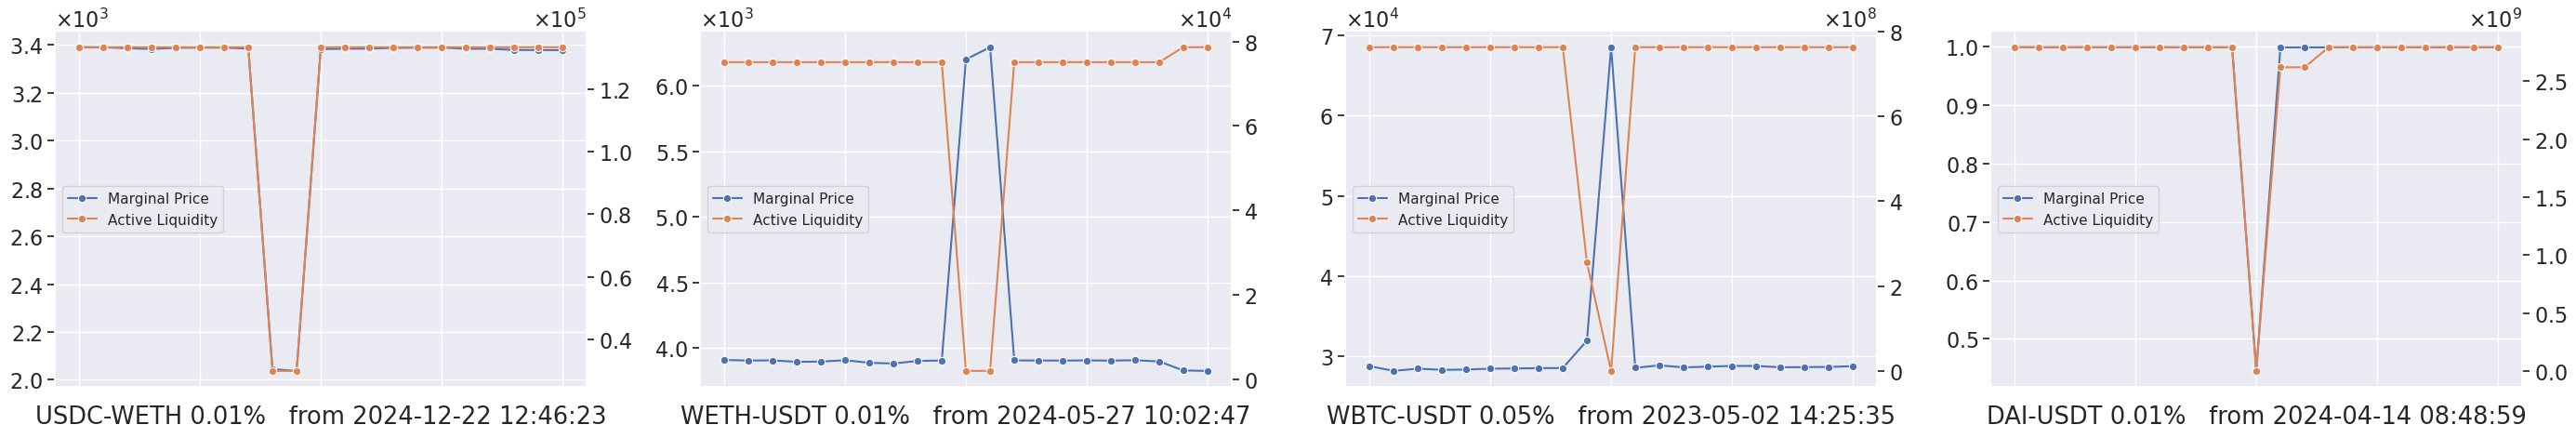

In [ ]:

# Price, Returns, and Liquidity
import matplotlib.ticker as mticker

fig, ax = plt.subplots(1, 4, figsize=(28, 5))

# Auxiliary function to handle the double axis, on the left and right sides
def force_sci(ax_):
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    formatter.set_useOffset(False)
    ax_.yaxis.set_major_formatter(formatter)

sub_p = 0

pool_name = 'usdc_weth_001'
curr_folder = f'{pool_name.upper()}/'
dataset_path = f'{data_path}{pool_name}.pickle'
with open(dataset_path, 'rb') as f:
    df_usdc_weth_001 = pickle.load(f)

df_usdc_weth_001 = df_usdc_weth_001[ (df_usdc_weth_001.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df_usdc_weth_001.index < datetime(2025, 1, 1, 0, 0, 0)) ]
df_usdc_weth_001 = df_usdc_weth_001.drop_duplicates()
df_usdc_weth_001['liquidity'] = df_usdc_weth_001.liquidity.ffill()
df_usdc_weth_001['price'] = df_usdc_weth_001.price.ffill()

temp_df = df_usdc_weth_001[829605-10:829605+11]
# Create right axis for p-values
ax2 = ax[sub_p].twinx()
sns.lineplot(x=range(len(temp_df)), y=temp_df.price.values, marker="o",
    color=sns.color_palette()[0], ax=ax[sub_p], label='Marginal Price')
sns.lineplot(x=range(len(temp_df)), y=temp_df.liquidity.values, marker="o",
    color=sns.color_palette()[1], ax=ax2, label='Active Liquidity', estimator=None)
force_sci(ax[sub_p])
force_sci(ax2)
ax[sub_p].set_xlabel('USDC-WETH 0.01%   from '+str(temp_df.index[0]))
ax[sub_p].set_ylabel('')
ax2.set_xlabel('')
ax2.set_xticklabels([])
ax2.set_ylabel('')
lines_1, labels_1 = ax[sub_p].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax[sub_p].legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left')
ax2.legend_.remove()
ax2.grid(False)

sub_p = 1

pool_name = 'weth_usdt_001'
curr_folder = f'{pool_name.upper()}/'
dataset_path = f'{data_path}{pool_name}.pickle'
with open(dataset_path, 'rb') as f:
    df_weth_usdt_001 = pickle.load(f)

df_weth_usdt_001 = df_weth_usdt_001[ (df_weth_usdt_001.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df_weth_usdt_001.index < datetime(2025, 1, 1, 0, 0, 0)) ]
df_weth_usdt_001 = df_weth_usdt_001.drop_duplicates()
df_weth_usdt_001['liquidity'] = df_weth_usdt_001.liquidity.ffill()
df_weth_usdt_001['price'] = df_weth_usdt_001.price.ffill()

temp_df = df_weth_usdt_001[506410-10:506410+11]
# Create right axis for p-values
ax2 = ax[sub_p].twinx()
sns.lineplot(x=range(len(temp_df)), y=temp_df.price.values, marker="o",
    color=sns.color_palette()[0], ax=ax[sub_p], label='Marginal Price')
sns.lineplot(x=range(len(temp_df)), y=temp_df.liquidity.values, marker="o",
    color=sns.color_palette()[1], ax=ax2, label='Active Liquidity', estimator=None)
force_sci(ax[sub_p])
force_sci(ax2)
ax[sub_p].set_xlabel('WETH-USDT 0.01%   from '+str(temp_df.index[0]))
ax[sub_p].set_ylabel('')
ax2.set_xlabel('')
ax2.set_xticklabels([])
ax2.set_ylabel('')

lines_1, labels_1 = ax[sub_p].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax[sub_p].legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left')
ax2.legend_.remove()
ax2.grid(False)

sub_p = 2

pool_name = 'wbtc_usdt_005'
curr_folder = f'{pool_name.upper()}/'
dataset_path = f'{data_path}{pool_name}.pickle'
with open(dataset_path, 'rb') as f:
    df_wbtc_usdt_005 = pickle.load(f)

df_wbtc_usdt_005 = df_wbtc_usdt_005[ (df_wbtc_usdt_005.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df_wbtc_usdt_005.index < datetime(2025, 1, 1, 0, 0, 0)) ]
df_wbtc_usdt_005 = df_wbtc_usdt_005.drop_duplicates()
df_wbtc_usdt_005['liquidity'] = df_wbtc_usdt_005.liquidity.ffill()
df_wbtc_usdt_005['price'] = df_wbtc_usdt_005.price.ffill()

temp_df = df_wbtc_usdt_005[1925-10:1925+11]
# Create right axis for p-values
ax2 = ax[sub_p].twinx()
sns.lineplot(x=range(len(temp_df)), y=temp_df.price.values, marker="o",
    color=sns.color_palette()[0], ax=ax[sub_p], label='Marginal Price')
sns.lineplot(x=range(len(temp_df)), y=temp_df.liquidity.values, marker="o",
    color=sns.color_palette()[1], ax=ax2, label='Active Liquidity', estimator=None)
force_sci(ax[sub_p])
force_sci(ax2)
ax[sub_p].set_xlabel('WBTC-USDT 0.05%   from '+str(temp_df.index[0]))
ax[sub_p].set_ylabel('')
ax2.set_xlabel('')
ax2.set_xticklabels([])
ax2.set_ylabel('')
lines_1, labels_1 = ax[sub_p].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax[sub_p].legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left')
ax2.legend_.remove()
ax2.grid(False)

sub_p = 3

pool_name = 'dai_usdt_001'
curr_folder = f'{pool_name.upper()}/'
dataset_path = f'{data_path}{pool_name}.pickle'
with open(dataset_path, 'rb') as f:
    df_dai_usdt_001 = pickle.load(f)

df_dai_usdt_001 = df_dai_usdt_001[ (df_dai_usdt_001.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df_dai_usdt_001.index < datetime(2025, 1, 1, 0, 0, 0)) ]
df_dai_usdt_001 = df_dai_usdt_001.drop_duplicates()
df_dai_usdt_001['liquidity'] = df_dai_usdt_001.liquidity.ffill()
df_dai_usdt_001['price'] = df_dai_usdt_001.price.ffill()

temp_df = df_dai_usdt_001[50821-10:50821+11]
# Create right axis for p-values
ax2 = ax[sub_p].twinx()
sns.lineplot(x=range(len(temp_df)), y=temp_df.price.values, marker="o",
    color=sns.color_palette()[0], ax=ax[sub_p], label='Marginal Price')
sns.lineplot(x=range(len(temp_df)), y=temp_df.liquidity.values, marker="o",
    color=sns.color_palette()[1], ax=ax2, label='Active Liquidity', estimator=None)
force_sci(ax[sub_p])
force_sci(ax2)
ax[sub_p].set_xlabel('DAI-USDT 0.01%   from '+str(temp_df.index[0]))
ax[sub_p].set_ylabel('')
ax2.set_xlabel('')
ax2.set_xticklabels([])
ax2.set_ylabel('')
lines_1, labels_1 = ax[sub_p].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax[sub_p].legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left')
ax2.legend_.remove()
ax2.grid(False)

plt.tight_layout()
#plt.savefig(f'../../figures/example_peaks_droughts.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


Generate / Load the Provision Summary showing, among the others, the effect of Liquidity Droughts

In [ ]:

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

if 'vol_vs_lp.pickle' in os.listdir(f'{main_dir}'):
    with open(f'{main_dir}vol_vs_lp.pickle', 'rb') as f:
        RV_Raw, RV_Star, Liq_Quantiles, Range_Tick, Total, Burn, Imbalance, Block_Time = pickle.load(f)
else:
    RV_Raw, RV_Star = dict(), dict()
    Liq_Quantiles, Range_Tick, Total, Burn = dict(), dict(), dict(), dict()
    Imbalance, Block_Time = dict(), dict()

    for pool_name in tqdm(Pools, desc="Iterating over the pool"):
        if pool_name not in list(Block_Time.keys()):
            curr_folder = f"{main_dir}{pool_name.upper()}/"
            os.chdir(curr_folder)
            dataset_path = f'{data_path}{pool_name}.pickle'
            
            #------------------------------ Swaps and Realized Variance
            with open(dataset_path, 'rb') as f:
                df = pickle.load(f)
            df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
            df = df.drop_duplicates()
            #------------------------------ Mint and Range Width
            with open(pool_name + '_jit.pickle', 'rb') as f:
                jit_flag = pickle.load(f)
            df["JIT_flag"] = jit_flag
            
            df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]

            lp_summary = utils_DevTrad.provision_summary(
                df_swap.price.to_numpy(dtype=np.float64, copy=False),
                df_swap.liquidity.to_numpy(dtype=np.float64, copy=False),
                df_swap.index.to_numpy(dtype='datetime64[ns]', copy=False),
                df[ (df.JIT_flag==0) & (df.Event=="Mint") ],
                df[ (df.JIT_flag==0) & (df.Event=="Burn") ],
                creation_period=df.index[0] > datetime(2023, 1, 2) )
            
            RV_Raw[Name_Pools[pool_name]] = lp_summary["rv_raw"]
            RV_Star[Name_Pools[pool_name]] = lp_summary["rv"]
            Liq_Quantiles[Name_Pools[pool_name]] = lp_summary["liq_quantiles"]
            Range_Tick[Name_Pools[pool_name]] = lp_summary["range_weighted"]
            Total[Name_Pools[pool_name]] = lp_summary["total_number"]
            Burn[Name_Pools[pool_name]] = lp_summary["burn_number"]
            Imbalance[Name_Pools[pool_name]] = lp_summary["burn_imbalance"]
            Block_Time[Name_Pools[pool_name]] = lp_summary["block_time"]

    with open(f'{main_dir}vol_vs_lp.pickle', 'wb') as f:
        pickle.dump([RV_Raw, RV_Star, Liq_Quantiles, Range_Tick, Total, Burn, Imbalance, Block_Time], f)


Iterating over the pool: 100%|██████████| 24/24 [00:42<00:00,  1.78s/it]


Show the plot RV^* / RV against \Delta L

R2 score from the Hill regression: 0.727975169999691


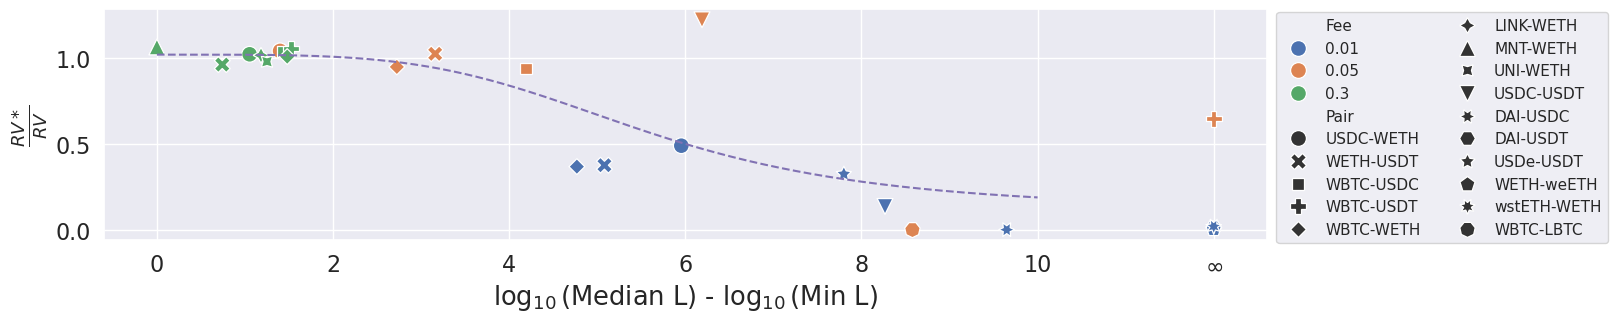

In [ ]:

from scipy.optimize import curve_fit

def hill(x: np.ndarray, low: float, high: float, x_half: float, slope: float) -> np.ndarray:
        return low + (high - low) / (1.0 + (x / x_half) ** slope)

df2plot = pd.DataFrame({
    'key':list(Liq_Quantiles.keys()),
    'x':np.log10(list(Liq_Quantiles.values()))[:,-1] - np.log10(list(Liq_Quantiles.values()))[:,0],
    'y':[k for k in (np.array(list(RV_Star.values()))/np.array(list(RV_Raw.values())))]})
df2plot['Pair'] = [k.split(' ')[0] for k in df2plot.key]
df2plot['Fee'] = [k.split(' ')[1].split("\\")[0] for k in df2plot.key]
df2plot['x'] = np.where(df2plot.x.values < np.inf, df2plot.x.values, 12)

fig, ax = plt.subplots(1, 1, figsize=(15, 3))

sns.scatterplot(df2plot, x='x', y='y', style='Pair', hue='Fee', s=130)

# Hill function fit
x_val = df2plot.x.values
y_val = df2plot.y.values
x_val = np.where(x_val>=12, 10e6, x_val)
x0 = np.median(x_val)

p0 = [np.min(y_val), np.max(y_val), x0, 2.0]
bounds = ([-np.inf, -np.inf, 1e-12, 0.0], [np.inf, np.inf, np.inf, np.inf])

popt, pcov = curve_fit(
    hill,
    x_val,
    y_val,
    p0=p0,
    bounds=bounds,
    maxfev=200000,
)

y_hat = hill(x_val, *popt)
ss_res = float(np.sum((y_val - y_hat) ** 2))
ss_tot = float(np.sum((y_val - np.mean(y_val)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
print(f"R2 score from the Hill regression: {r2}")

x_grid = np.linspace(np.min(x_val), 10, 500)
sns.lineplot(x=x_grid, y=hill(x_grid, *popt), linestyle="--", color=sns.color_palette()[4])

ax.set_xlabel(r'$\log_{10}$(Median L) - $\log_{10}$(Min L)')
ax.set_ylabel(r'$\frac{RV*}{RV}$')

ax.set_xticklabels(['0', '0', '2', '4', '6', '8', '10', r'$\infty$'])

plt.legend( loc="upper right", bbox_to_anchor=(1.30, 1.02), ncol=2 )

#plt.savefig(f'delta_rv_L.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


Delta tick and Provision Time as a function of RV^*

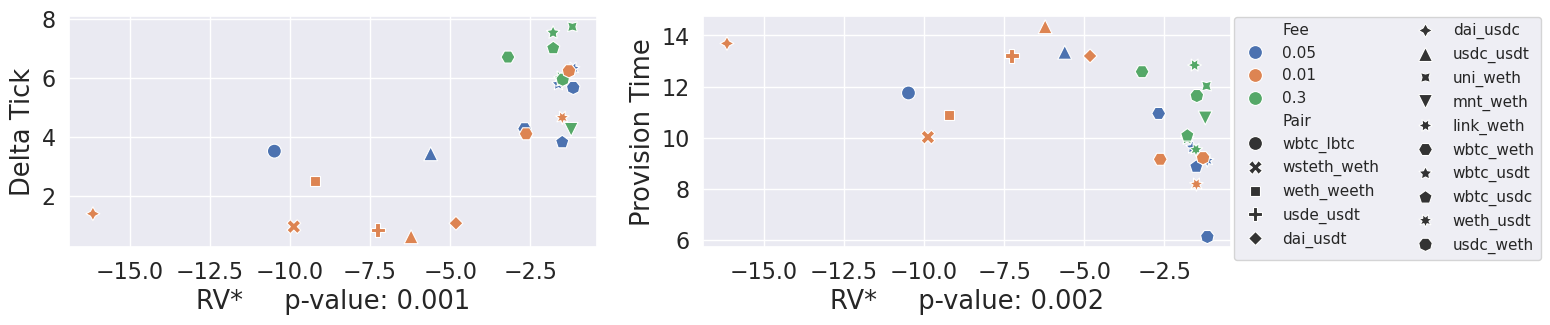

In [ ]:

from scipy.stats import permutation_test, spearmanr

Name_Pools_Invers = dict([[v, k] for k,v in Name_Pools.items()])

np.random.seed(2)
left_pval = permutation_test(
    (np.log(list(RV_Star.values())),), lambda x: spearmanr(x, np.log(list(Range_Tick.values()))).statistic, permutation_type='pairings').pvalue

np.random.seed(2)
right_pval = permutation_test(
    (np.log(list(RV_Star.values())),), lambda x: spearmanr(x, np.log(list(Block_Time.values()))).statistic, permutation_type='pairings').pvalue

fig, ax = plt.subplots(1, 2, figsize=(15, 3))#, gridspec_kw={'wspace':0.05})

sub_p = 0
df2plot = pd.DataFrame({'key':[Name_Pools_Invers[k] for k in RV_Star.keys()][::-1], 'x':np.log(list(RV_Star.values())[::-1]), 'y':np.log(list(Range_Tick.values())[::-1])})
df2plot['Pair'] = [k.split('_')[0]+'_'+k.split('_')[1] for k in df2plot.key]
df2plot['Fee'] = ['0.'+k.split('_')[-1][1:] for k in df2plot.key]
df2plot_test = df2plot[['x', 'y']][ df2plot.y > 152 ]
sns.scatterplot(df2plot, x='x', y='y', style='Pair', hue='Fee', s=100, ax=ax[sub_p])
ax[sub_p].set_xlabel(f'RV*     p-value: {left_pval:.3f}')
ax[sub_p].set_ylabel('Delta Tick')
ax[sub_p].legend_.remove()

sub_p = 1
df2plot = pd.DataFrame({'key':[Name_Pools_Invers[k] for k in RV_Star.keys()][::-1], 'x':np.log(list(RV_Star.values())[::-1]), 'y':np.log(list(Block_Time.values())[::-1])})
df2plot['Pair'] = [k.split('_')[0]+'_'+k.split('_')[1] for k in df2plot.key]
df2plot['Fee'] = ['0.'+k.split('_')[-1][1:] for k in df2plot.key]
df2plot_test = df2plot[['x', 'y']][ df2plot.y > 152 ]
sns.scatterplot(df2plot, x='x', y='y', style='Pair', hue='Fee', s=100, ax=ax[sub_p])

ax[sub_p].set_xlabel(f'RV*     p-value: {right_pval}')
ax[sub_p].set_ylabel('Provision Time')

plt.legend(
    loc="upper right", bbox_to_anchor=(1.6, 1.03), ncol=2 )

#plt.savefig(f'lp_vs_rv.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


### Split ACF at lag 1

Split the ACF at lag 1 conditional on the previous return's magnitude. First, define auxiliary functions

In [ ]:

def calculate_sign_change_probabilities(returns, phi=0.003):
    """
    Calculate the probability of sign change conditional on absolute return size.
    Returns:
    - prob_large: P(sign change | |r_t| > phi)
    - prob_small: P(sign change | |r_t| < phi)
    """

    signs = np.sign(returns) #Get signs of returns
    sign_changes = (signs[:-1] * signs[1:]) < 0 #Calculate sign changes (1 if sign changes, 0 otherwise)
    abs_returns = np.abs(returns[:-1]) #Get absolute returns (excluding last one since we look at t+1)

    # Split based on phi threshold
    large_return_mask = abs_returns > phi
    small_return_mask = abs_returns <= phi

    # Calculate conditional probabilities
    if np.sum(large_return_mask) > 0:
        prob_large = np.mean(sign_changes[large_return_mask])
    else:
        prob_large = np.nan

    if np.sum(small_return_mask) > 0:
        prob_small = np.mean(sign_changes[small_return_mask])
    else:
        prob_small = np.nan

    return prob_large, prob_small


def bootstrap_sign_test(x_train, phi=0.003, n_bootstrap=1000, seed=None):
    """
    Perform one-sided bootstrap test.
    H0: P(sign change | |r_t| > phi) < P(sign change | |r_t| < phi)
    H1: P(sign change | |r_t| > phi) >= P(sign change | |r_t| < phi)
    Returns:
    - p_value: one-sided p-value
    - test_statistic: observed test statistic
    - bootstrap_distribution: array of bootstrap test statistics
    """

    np.random.seed(seed)

    # Calculate observed test statistic
    prob_large_obs, prob_small_obs = calculate_sign_change_probabilities(x_train, phi)
    test_statistic = prob_large_obs - prob_small_obs

    # Bootstrap procedure
    bootstrap_stats = []
    n = len(x_train)
    for i in range(n_bootstrap):
        # Resample with replacement
        # Important: we need to preserve the time series structure somewhat
        # So we'll use block bootstrap or just regular bootstrap

        # Option 1: Regular bootstrap (assumes returns are roughly independent)
        bootstrap_indices = np.random.choice(n-1, size=n-1, replace=True)
        bootstrap_returns = x_train[bootstrap_indices]
        bootstrap_returns_next = x_train[bootstrap_indices + 1]
        # Reconstruct the series
        bootstrap_series = np.concatenate([bootstrap_returns[:1], bootstrap_returns_next])
        # Calculate test statistic for bootstrap sample
        prob_large_boot, prob_small_boot = calculate_sign_change_probabilities(bootstrap_series, phi)
        if not np.isnan(prob_large_boot) and not np.isnan(prob_small_boot):
            bootstrap_stats.append(prob_large_boot - prob_small_boot)
    bootstrap_stats = np.array(bootstrap_stats)

    # Calculate one-sided p-value
    # Since H0: difference < 0, we want P(bootstrap_stat >= observed_stat | H0)
    # Under the null, we center the bootstrap distribution
    centered_bootstrap_stats = bootstrap_stats - np.mean(bootstrap_stats)
    p_value = np.mean(centered_bootstrap_stats >= test_statistic)

    return p_value, test_statistic


Study the ACF in swap-time

In [ ]:

from statsmodels.tsa.stattools import acf

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

for n_p, name in enumerate(Pools):
    curr_folder = f"{main_dir}{name.upper()}/"
    os.chdir(curr_folder)
    dataset_path = f'{data_path}{name}.pickle'
    
    #------------------------------ Swaps and Realized Variance
    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)

    df.index = pd.to_datetime(df.index)
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()

    x_train = np.log(df_swap.price).diff().to_numpy(copy=False)[1:]
    phi = float('0.'+name.split('_')[-1][1:])/100

    # Run the test
    p_value, _ = bootstrap_sign_test(x_train, phi=2*phi, n_bootstrap=1000, seed=2)
    to_print = Name_Pools[name]
    to_print += ' & '

    acf_raw = acf(x_train, nlags=1, alpha=0.05)
    lb5, ub5 = acf_raw[-1][1]
    acf_raw = acf_raw[0][1]
    lb1, ub1 = acf(x_train, nlags=1, alpha=0.01)[-1][1]
    to_print += str('{:.3f}'.format(acf_raw))
    to_print += ' & '

    lag = 1
    temp_mask = np.where(np.abs(x_train[:-lag]) > phi, True, False)
    temp_acf = (np.mean((x_train[lag:] * x_train[:-lag])[temp_mask]) - np.mean(x_train[lag:][temp_mask])*np.mean(x_train[:-lag][temp_mask])) / (
        np.std(x_train[lag:][temp_mask]) * np.std(x_train[:-lag][temp_mask]) )
    if temp_acf < lb5:
        if temp_acf < lb1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    elif temp_acf > ub5:
        if temp_acf > ub1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    else:
        to_print += str('{:.3f}'.format( temp_acf ))
    to_print += ' & '

    temp_mask = np.where(np.abs(x_train[:-lag]) <= phi, True, False)
    temp_acf = (np.mean((x_train[lag:] * x_train[:-lag])[temp_mask]) - np.mean(x_train[lag:][temp_mask])*np.mean(x_train[:-lag][temp_mask])) / (
        np.std(x_train[lag:][temp_mask]) * np.std(x_train[:-lag][temp_mask]) )
    if temp_acf < lb5:
        if temp_acf < lb1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    elif temp_acf > ub5:
        if temp_acf > ub1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    else:
        to_print += str('{:.3f}'.format( temp_acf ))
    to_print += ' \\\\'

    print(to_print)
    print('\n')



USDC-WETH 0.01\% & -0.014 & -0.015 & \textbf{0.000} \\


USDC-WETH 0.05\% & -0.042 & \textbf{-0.071} & \textbf{0.038} \\


USDC-WETH 0.3\% & 0.029 & \textbf{-0.210} & \textbf{0.296} \\


WETH-USDT 0.01\% & -0.026 & \textbf{-0.032} & \textbf{-0.002} \\


WETH-USDT 0.05\% & -0.035 & \textbf{-0.046} & \textbf{0.010} \\


WETH-USDT 0.3\% & 0.016 & \textbf{-0.194} & \textbf{0.259} \\


WBTC-USDC 0.05\% & -0.133 & \textbf{-0.139} & \textbf{0.003} \\


WBTC-USDC 0.3\% & 0.003 & \textbf{-0.231} & \textbf{0.385} \\


WBTC-USDT 0.05\% & -0.218 & \underline{-0.226} & \textbf{0.022} \\


WBTC-USDT 0.3\% & 0.020 & \textbf{-0.128} & \textbf{0.301} \\


WBTC-WETH 0.01\% & -0.270 & -0.271 & \textbf{0.004} \\


WBTC-WETH 0.05\% & -0.089 & \textbf{-0.124} & \textbf{0.074} \\


WBTC-WETH 0.3\% & 0.056 & \textbf{-0.142} & \textbf{0.256} \\


LINK-WETH 0.3\% & -0.158 & \textbf{-0.414} & \textbf{0.211} \\


MNT-WETH 0.3\% & -0.000 & \textbf{-0.122} & \textbf{0.166} \\


UNI-WETH 0.3\% & -0.077 & \textbf{-0.

Now, consider block-time

In [ ]:

from statsmodels.tsa.stattools import acf

Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

for n_p, name in enumerate(Pools):
    curr_folder = f"{main_dir}{name.upper()}/"
    os.chdir(curr_folder)
    dataset_path = f'{data_path}{name}.pickle'
    
    #------------------------------ Swaps and Realized Variance
    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)

    df.index = pd.to_datetime(df.index)
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()

    x_train = np.log(df_swap.groupby("block_number").price.last()).diff().to_numpy(copy=False)[1:]
    phi = float('0.'+name.split('_')[-1][1:])/100

    # Run the test
    p_value, _ = bootstrap_sign_test(x_train, phi=2*phi, n_bootstrap=1000, seed=2)
    to_print = Name_Pools[name]
    to_print += ' & '

    acf_raw = acf(x_train, nlags=1, alpha=0.05)
    lb5, ub5 = acf_raw[-1][1]
    acf_raw = acf_raw[0][1]
    lb1, ub1 = acf(x_train, nlags=1, alpha=0.01)[-1][1]
    to_print += str('{:.3f}'.format(acf_raw))
    to_print += ' & '

    lag = 1
    temp_mask = np.where(np.abs(x_train[:-lag]) > phi, True, False)
    temp_acf = (np.mean((x_train[lag:] * x_train[:-lag])[temp_mask]) - np.mean(x_train[lag:][temp_mask])*np.mean(x_train[:-lag][temp_mask])) / (
        np.std(x_train[lag:][temp_mask]) * np.std(x_train[:-lag][temp_mask]) )
    if temp_acf < lb5:
        if temp_acf < lb1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    elif temp_acf > ub5:
        if temp_acf > ub1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    else:
        to_print += str('{:.3f}'.format( temp_acf ))
    to_print += ' & '

    temp_mask = np.where(np.abs(x_train[:-lag]) <= phi, True, False)
    temp_acf = (np.mean((x_train[lag:] * x_train[:-lag])[temp_mask]) - np.mean(x_train[lag:][temp_mask])*np.mean(x_train[:-lag][temp_mask])) / (
        np.std(x_train[lag:][temp_mask]) * np.std(x_train[:-lag][temp_mask]) )
    if temp_acf < lb5:
        if temp_acf < lb1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    elif temp_acf > ub5:
        if temp_acf > ub1:
            to_print += '\\textbf{' + str('{:.3f}'.format( temp_acf )) + '}'
        else:
            to_print += '\\underline{' + str('{:.3f}'.format( temp_acf )) + '}'
    else:
        to_print += str('{:.3f}'.format( temp_acf ))
    to_print += ' \\\\'

    print(to_print)
    print('\n')


USDC-WETH 0.01\% & -0.281 & \textbf{-0.295} & \textbf{0.016} \\


USDC-WETH 0.05\% & -0.066 & \textbf{-0.147} & \textbf{0.158} \\


USDC-WETH 0.3\% & -0.023 & \textbf{-0.388} & \textbf{0.363} \\


WETH-USDT 0.01\% & -0.255 & \textbf{-0.268} & \textbf{0.008} \\


WETH-USDT 0.05\% & -0.102 & \textbf{-0.165} & \textbf{0.079} \\


WETH-USDT 0.3\% & 0.043 & \textbf{-0.248} & \textbf{0.337} \\


WBTC-USDC 0.05\% & -0.126 & \textbf{-0.142} & \textbf{0.089} \\


WBTC-USDC 0.3\% & 0.028 & \textbf{-0.279} & \textbf{0.425} \\


WBTC-USDT 0.05\% & -0.141 & -0.148 & \textbf{0.110} \\


WBTC-USDT 0.3\% & 0.011 & \textbf{-0.291} & \textbf{0.379} \\


WBTC-WETH 0.01\% & -0.366 & -0.370 & \textbf{0.063} \\


WBTC-WETH 0.05\% & -0.076 & \textbf{-0.207} & \textbf{0.201} \\


WBTC-WETH 0.3\% & -0.022 & \textbf{-0.367} & \textbf{0.331} \\


LINK-WETH 0.3\% & -0.060 & \textbf{-0.429} & \textbf{0.294} \\


MNT-WETH 0.3\% & 0.020 & \textbf{-0.133} & \textbf{0.208} \\


UNI-WETH 0.3\% & -0.044 & \textbf{-0.362

### Test Long-Memory - Abs, Vol, Sign

Compute the p coefficient on the whole series (Table 8) with different approaches. Work with Absolute Value, Volume, and Sign time series; both swap-time and block-time

In [ ]:

from statsmodels.tsa.stattools import acf
from sklearn.linear_model import LinearRegression

nlags = 1_500
start_l, end_l = 10, nlags

# RV*/RV Against log10(Median L) - log10(Min L)
Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

Results = {"Abs":dict(), "Vol":dict(), "Sign":dict()}
Results_block = {"Abs":dict(), "Vol":dict(), "Sign":dict()}
for pool_name in tqdm(Pools, desc="Iterating over the pool"):
    if pool_name in list(Results_block["Sign"].keys()):
        continue
    
    curr_folder = f"{main_dir}{pool_name.upper()}/"
    os.chdir(curr_folder)
    dataset_path = f'{data_path}{pool_name}.pickle'

    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)
    df.index = pd.to_datetime(df.index)
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()

    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()

    #------------------------------------------------
    #----------------------Abs-----------------------
    #------------------------------------------------
    x_train = np.log(df_swap.price.values)
    x_train = np.abs(x_train[1:] - x_train[:-1])

    acf_swap = acf(x_train, nlags=nlags)
    X_temp = acf_swap[start_l:end_l]
    pos_cond = X_temp>0
    mdl_p = LinearRegression(fit_intercept=True)
    mdl_p.fit(
        np.log(range(start_l, end_l)).reshape(-1, 1)[pos_cond],
        np.log(X_temp[pos_cond]))
    curr_res = utils_DevTrad.long_memory_test(x_train)

    Results["Abs"][pool_name] = dict()
    Results["Abs"][pool_name]["Loglog"] = mdl_p.coef_[0]
    Results["Abs"][pool_name]["RS"] = 2 * (1 - curr_res["rs_hurst"])
    Results["Abs"][pool_name]["Period"] = 2 * (1 - curr_res["periodogram_hurst"])
    Results["Abs"][pool_name]["DFA"] = 2 * (1 - curr_res["dfa_hurst"])

    x_train_block = np.log(df_swap.groupby("block_number").price.last().values)
    x_train_block = np.abs(x_train_block[1:] - x_train_block[:-1])

    acf_swap_block = acf(x_train_block, nlags=nlags)
    X_temp_block = acf_swap_block[start_l:end_l]
    pos_cond_block = X_temp_block>0
    mdl_p_block = LinearRegression(fit_intercept=True)
    mdl_p_block.fit(
        np.log(range(start_l, end_l)).reshape(-1, 1)[pos_cond_block],
        np.log(X_temp_block[pos_cond_block]))
    curr_res_block = utils_DevTrad.long_memory_test(x_train_block)

    Results_block["Abs"][pool_name] = dict()
    Results_block["Abs"][pool_name]["Loglog"] = mdl_p_block.coef_[0]
    Results_block["Abs"][pool_name]["RS"] = 2 * (1 - curr_res_block["rs_hurst"])
    Results_block["Abs"][pool_name]["Period"] = 2 * (1 - curr_res_block["periodogram_hurst"])
    Results_block["Abs"][pool_name]["DFA"] = 2 * (1 - curr_res_block["dfa_hurst"])

    #------------------------------------------------
    #----------------------vol-----------------------
    #------------------------------------------------
    df_swap["amount"] = df_swap.amount1.abs()
    x_train = df_swap.amount.values

    acf_swap = acf(x_train, nlags=nlags)
    X_temp = acf_swap[start_l:end_l]
    pos_cond = X_temp>0
    mdl_p = LinearRegression(fit_intercept=True)
    mdl_p.fit(
        np.log(range(start_l, end_l)).reshape(-1, 1)[pos_cond],
        np.log(X_temp[pos_cond]))
    curr_res = utils_DevTrad.long_memory_test(x_train)
    
    Results["Vol"][pool_name] = dict()
    Results["Vol"][pool_name]["Loglog"] = mdl_p.coef_[0]
    Results["Vol"][pool_name]["RS"] = 2 * (1 - curr_res["rs_hurst"])
    Results["Vol"][pool_name]["Period"] = 2 * (1 - curr_res["periodogram_hurst"])
    Results["Vol"][pool_name]["DFA"] = 2 * (1 - curr_res["dfa_hurst"])

    x_train_block = df_swap.groupby("block_number").amount.sum().values

    acf_swap_block = acf(x_train_block, nlags=nlags)
    X_temp_block = acf_swap_block[start_l:end_l]
    pos_cond_block = X_temp_block>0
    mdl_p_block = LinearRegression(fit_intercept=True)
    mdl_p_block.fit(
        np.log(range(start_l, end_l)).reshape(-1, 1)[pos_cond_block],
        np.log(X_temp_block[pos_cond_block]))
    curr_res_block = utils_DevTrad.long_memory_test(x_train_block)

    Results_block["Vol"][pool_name] = dict()
    Results_block["Vol"][pool_name]["Loglog"] = mdl_p_block.coef_[0]
    Results_block["Vol"][pool_name]["RS"] = 2 * (1 - curr_res_block["rs_hurst"])
    Results_block["Vol"][pool_name]["Period"] = 2 * (1 - curr_res_block["periodogram_hurst"])
    Results_block["Vol"][pool_name]["DFA"] = 2 * (1 - curr_res_block["dfa_hurst"])

    #------------------------------------------------
    #----------------------Sign----------------------
    #------------------------------------------------
    x_train = np.where(df_swap.Event=="Swap_X2Y", 1, 0)

    acf_swap = acf(x_train, nlags=nlags)
    X_temp = acf_swap[start_l:end_l]
    pos_cond = X_temp>0
    mdl_p = LinearRegression(fit_intercept=True)
    mdl_p.fit(
        np.log(range(start_l, end_l)).reshape(-1, 1)[pos_cond],
        np.log(X_temp[pos_cond]))
    curr_res = utils_DevTrad.long_memory_test(x_train)
    
    Results["Sign"][pool_name] = dict()
    Results["Sign"][pool_name]["Loglog"] = mdl_p.coef_[0]
    Results["Sign"][pool_name]["RS"] = 2 * (1 - curr_res["rs_hurst"])
    Results["Sign"][pool_name]["Period"] = 2 * (1 - curr_res["periodogram_hurst"])
    Results["Sign"][pool_name]["DFA"] = 2 * (1 - curr_res["dfa_hurst"])

    df_swap["Event_I"] = np.where(df_swap.Event=="Swap_X2Y", 1, 0)
    x_train_block = df_swap.groupby("block_number").Event_I.mean().values

    acf_swap_block = acf(x_train_block, nlags=nlags)
    X_temp_block = acf_swap_block[start_l:end_l]
    pos_cond_block = X_temp_block>0
    mdl_p_block = LinearRegression(fit_intercept=True)
    mdl_p_block.fit(
        np.log(range(start_l, end_l)).reshape(-1, 1)[pos_cond_block],
        np.log(X_temp_block[pos_cond_block]))
    curr_res_block = utils_DevTrad.long_memory_test(x_train_block)

    Results_block["Sign"][pool_name] = dict()
    Results_block["Sign"][pool_name]["Loglog"] = mdl_p_block.coef_[0]
    Results_block["Sign"][pool_name]["RS"] = 2 * (1 - curr_res_block["rs_hurst"])
    Results_block["Sign"][pool_name]["Period"] = 2 * (1 - curr_res_block["periodogram_hurst"])
    Results_block["Sign"][pool_name]["DFA"] = 2 * (1 - curr_res_block["dfa_hurst"])

    #------------------------------------------------
    #----------------------Save----------------------
    #------------------------------------------------
    
    with open(f'{main_dir}General/long_memory.pickle', 'wb') as f: 
        pickle.dump([Results, Results_block], f)


Iterating over the pool:   0%|          | 0/24 [00:00<?, ?it/s]

Iterating over the pool: 100%|██████████| 24/24 [02:16<00:00,  5.69s/it]


Table 8, in the paper appendix

In [ ]:

with open(f'{main_dir}General/long_memory.pickle', 'rb') as f: 
    Results, Results_block = pickle.load(f)

for pool_name in Pools:
    to_print = "\\multirow{2}{*}{\\texttt{"+f"{Name_Pools[pool_name]}"+"}} "
    for series in ["Abs", "Vol", "Sign"]:
        to_print += f'& {Results[series][pool_name]["RS"]:.2f} & {Results[series][pool_name]["Period"]:.2f} & {Results[series][pool_name]["DFA"]:.2f}'
    print(to_print + "\\\\")

    to_print = f" "
    for series in ["Abs", "Vol", "Sign"]:
        to_print += f'& {Results_block[series][pool_name]["RS"]:.2f} & {Results_block[series][pool_name]["Period"]:.2f} & {Results_block[series][pool_name]["DFA"]:.2f}'
    print(to_print + "\\\\")


\multirow{2}{*}{\texttt{USDC-WETH 0.01\%}} & 0.72 & 0.97 & 0.77& 0.51 & 0.84 & 0.44& 0.72 & 0.79 & 0.71\\
 & 0.29 & 0.31 & 0.28& 0.53 & 0.79 & 0.45& 0.74 & 0.82 & 0.72\\
\multirow{2}{*}{\texttt{USDC-WETH 0.05\%}} & 0.40 & 0.60 & 0.30& 0.44 & 0.68 & 0.45& 0.59 & 0.74 & 0.56\\
 & 0.34 & 0.30 & 0.28& 0.45 & 0.55 & 0.41& 0.60 & 0.80 & 0.58\\
\multirow{2}{*}{\texttt{USDC-WETH 0.3\%}} & 0.47 & 0.24 & 0.33& 0.43 & 0.45 & 0.38& 0.66 & 0.49 & 0.64\\
 & 0.45 & 0.18 & 0.34& 0.43 & 0.38 & 0.40& 0.66 & 0.55 & 0.65\\
\multirow{2}{*}{\texttt{WETH-USDT 0.01\%}} & 0.65 & 0.78 & 0.69& 0.57 & 0.84 & 0.54& 0.71 & 0.81 & 0.70\\
 & 0.30 & 0.31 & 0.32& 0.58 & 0.83 & 0.58& 0.72 & 0.83 & 0.72\\
\multirow{2}{*}{\texttt{WETH-USDT 0.05\%}} & 0.44 & 0.84 & 0.47& 0.40 & 0.67 & 0.34& 0.61 & 0.83 & 0.58\\
 & 0.33 & 0.22 & 0.25& 0.44 & 0.55 & 0.34& 0.63 & 0.85 & 0.60\\
\multirow{2}{*}{\texttt{WETH-USDT 0.3\%}} & 0.42 & 0.32 & 0.29& 0.42 & 0.42 & 0.33& 0.59 & 0.49 & 0.57\\
 & 0.42 & 0.26 & 0.32& 0.45 & 0.41 & 0.33& 0.6

Compute the whole distribution of the p coefficients to be plotted in Figure 15

In [50]:

# Compute p-val distributions
nlags = 1_500
start_l, end_l = 10, nlags

# RV*/RV Against log10(Median L) - log10(Min L)
Pools = [
    'usdc_weth_001', 'usdc_weth_005', 'usdc_weth_03', 'weth_usdt_001', 'weth_usdt_005', 'weth_usdt_03',
    'wbtc_usdc_005', 'wbtc_usdc_03', 'wbtc_usdt_005', 'wbtc_usdt_03',
    'wbtc_weth_001', 'wbtc_weth_005', 'wbtc_weth_03', 'link_weth_03', 'mnt_weth_03', 'uni_weth_03',
    'usdc_usdt_001', 'usdc_usdt_005', 'dai_usdc_001', 'dai_usdt_001', 'usde_usdt_001',
    'weth_weeth_001', 'wsteth_weth_001', 'wbtc_lbtc_005' ]

Name_Pools = dict([[k, (k.split('_')[0]+'-'+k.split('_')[1]).upper()+' 0.'+k.split('_')[2][1:]+'\%'] for k in Pools])
Name_Pools['usde_usdt_001'] = 'USDe-USDT 0.01\%'
Name_Pools['weth_weeth_001'] = 'WETH-weETH 0.01\%'
Name_Pools['wsteth_weth_001'] = 'wstETH-WETH 0.01\%'

Results = dict()

# Load the one-shot version for fetching the total value
with open(f'{main_dir}General/long_memory.pickle', 'rb') as f: 
    Results_tot, _ = pickle.load(f)

for pool_name in tqdm(Pools, desc="Iterating over the pool"):
    curr_folder = f"{main_dir}{pool_name.upper()}/"
    os.chdir(curr_folder)
    dataset_path = f'{data_path}{pool_name}.pickle'

    with open(dataset_path, 'rb') as f:
        df = pickle.load(f)
    df.index = pd.to_datetime(df.index)
    df = df[ (df.index >= datetime(2023, 1, 1, 0, 0, 0)) & (df.index < datetime(2025, 1, 1, 0, 0, 0)) ]
    df = df.drop_duplicates()

    df_swap = df[ (df.Event=='Swap_X2Y') | (df.Event=='Swap_Y2X') ]
    df_swap = df_swap.drop_duplicates()

    Results[pool_name] = dict()

    #------------------------------------------------
    #----------------------Abs-----------------------
    #------------------------------------------------
    x_train = np.log(df_swap.price.values)
    x_train = np.abs(x_train[1:] - x_train[:-1])

    curr_res = utils_DevTrad.long_memory_H_dist(x_train)
    Results[pool_name]["Abs_dist"] = 2 * (1 - np.array(
        curr_res["median_hurst"]))
    Results[pool_name]["Abs"] = np.nanmedian([
        Results_tot["Abs"][pool_name]["RS"],
        Results_tot["Abs"][pool_name]["Period"],
        Results_tot["Abs"][pool_name]["DFA"]
    ])

    #------------------------------------------------
    #----------------------vol-----------------------
    #------------------------------------------------
    df_swap["amount"] = df_swap.amount1.abs()
    x_train = df_swap.amount.values
    
    curr_res = utils_DevTrad.long_memory_H_dist(x_train)
    
    Results[pool_name]["Vol_dist"] = 2 * (1 - np.array(
        curr_res["median_hurst"]))
    Results[pool_name]["Vol"] = np.nanmedian([
        Results_tot["Vol"][pool_name]["RS"],
        Results_tot["Vol"][pool_name]["Period"],
        Results_tot["Vol"][pool_name]["DFA"]
    ])

    #------------------------------------------------
    #----------------------Sign----------------------
    #------------------------------------------------
    x_train = np.where(df_swap.Event=="Swap_X2Y", 1, 0)
    
    curr_res = utils_DevTrad.long_memory_H_dist(x_train)

    Results[pool_name]["Sign_dist"] = 2 * (1 - np.array(
        curr_res["median_hurst"]))
    Results[pool_name]["Sign"] = np.nanmedian([
        Results_tot["Sign"][pool_name]["RS"],
        Results_tot["Sign"][pool_name]["Period"],
        Results_tot["Sign"][pool_name]["DFA"]
    ])

    #------------------------------------------------
    #----------------------Save----------------------
    #------------------------------------------------
    
    with open(f'{main_dir}General/long_memory_dist.pickle', 'wb') as f: 
        pickle.dump(Results, f)

Iterating over the pool: 100%|██████████| 24/24 [01:04<00:00,  2.67s/it]


Plot Figure 15

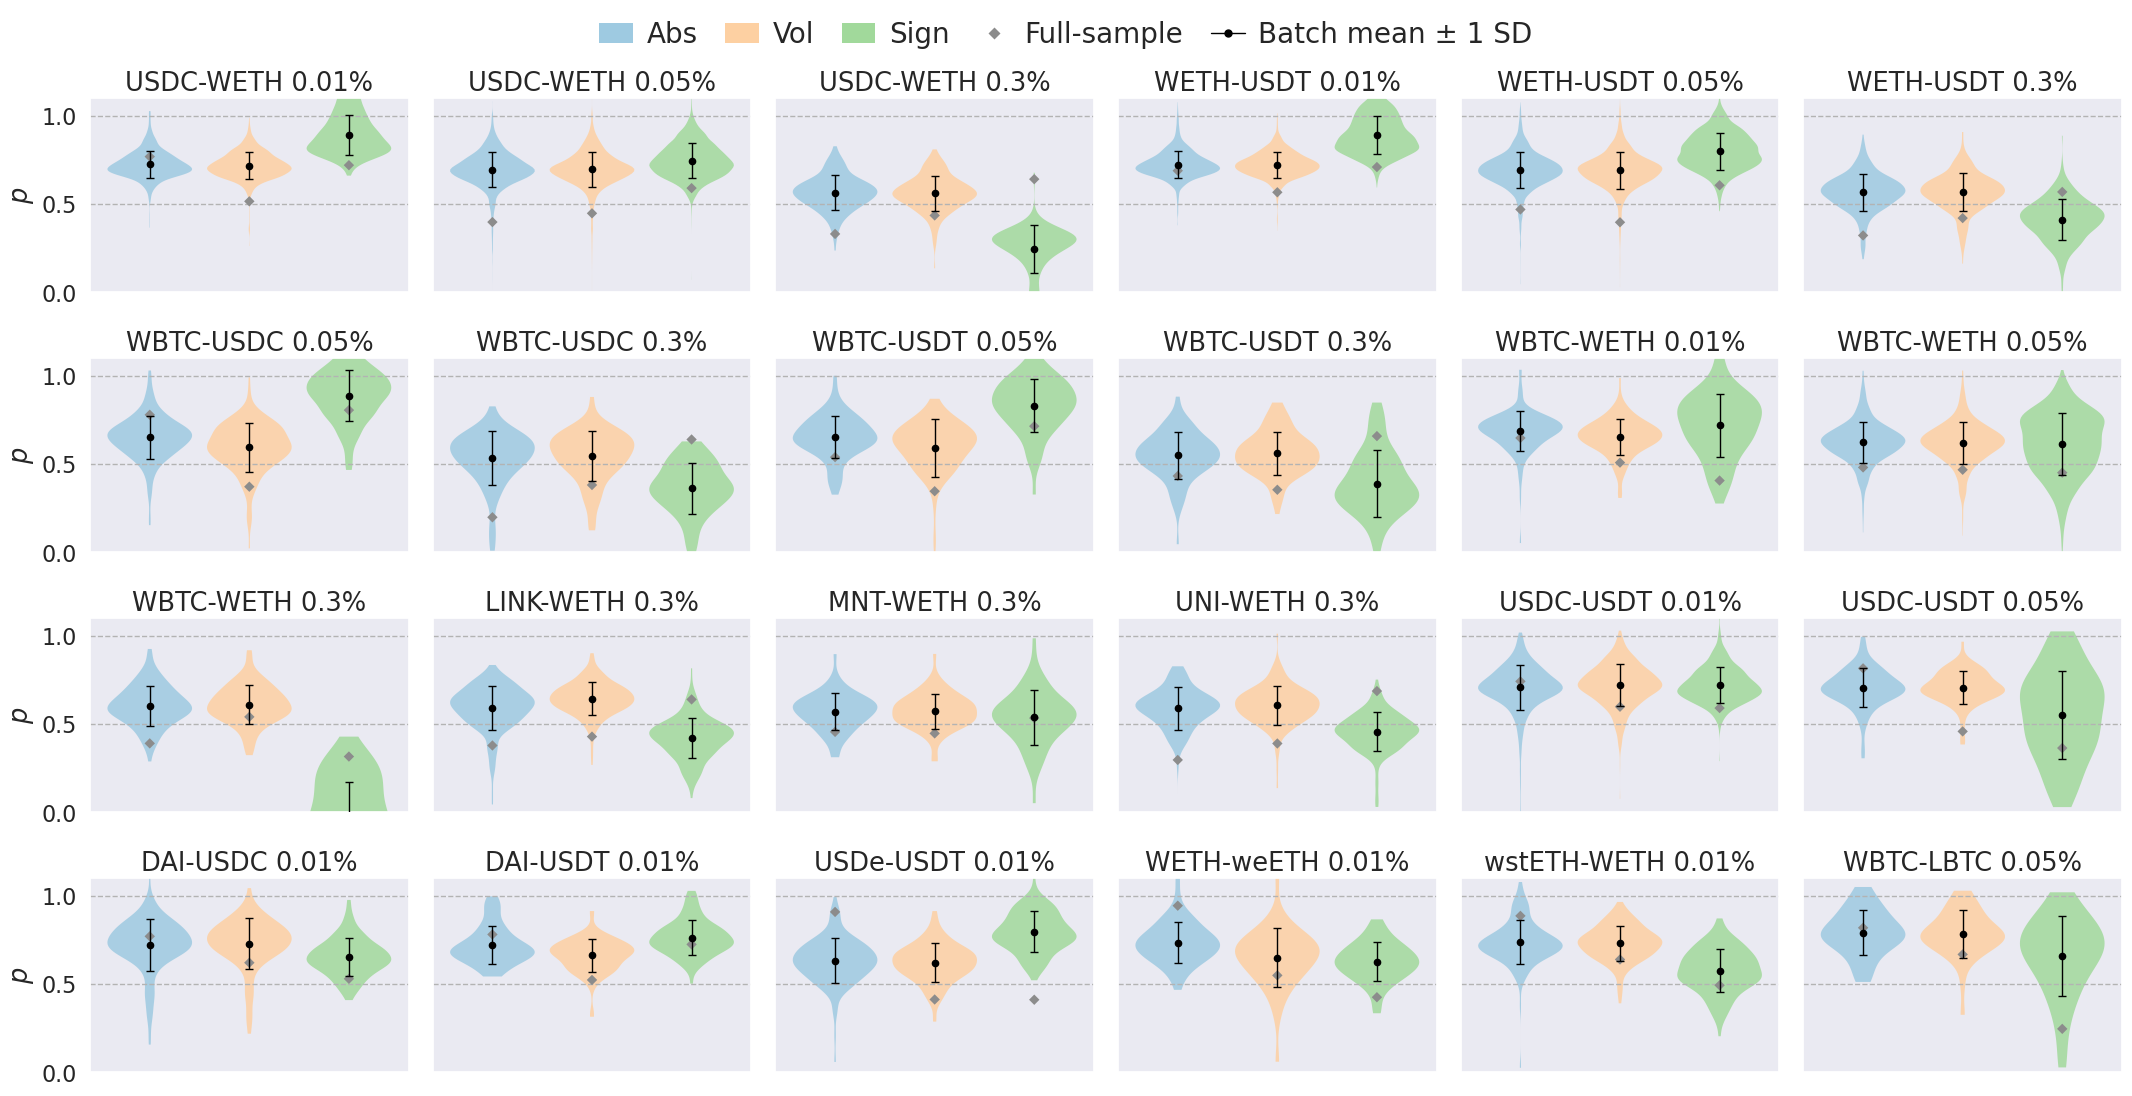

In [51]:

import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot for the main paper
with open(f'{main_dir}General/long_memory_dist.pickle', 'rb') as f: 
    Results = pickle.load(f)

ncols = 6
figsize_per_col = 3.6
figsize_per_row = 2.8
show_batch_mean_sd = True
sharey = True

method_order = ["Abs", "Vol", "Sign"]
dist_keys = ["Abs_dist", "Vol_dist", "Sign_dist"]
method_labels = {"Abs": "Abs", "Vol": "Vol", "Sign": "Sign"}

colors = {
    "Abs": "#9ecae1",
    "Vol": "#fdd0a2",
    "Sign": "#a1d99b",
}

pool_group = {
    "usdc_weth_001": "Normal", "usdc_weth_005": "Normal", "usdc_weth_03": "Normal",
    "weth_usdt_001": "Normal", "weth_usdt_005": "Normal", "weth_usdt_03": "Normal",
    "wbtc_usdc_005": "Normal", "wbtc_usdc_03": "Normal", "wbtc_usdt_005": "Normal", "wbtc_usdt_03": "Normal",
    "dai_usdc_001": "Stable", "usdc_usdt_001": "Stable", "usdc_usdt_005": "Stable",
    "dai_usdt_001": "Stable", "usde_usdt_001": "Stable",
    "wbtc_weth_001": "Volatile", "wbtc_weth_005": "Volatile", "wbtc_weth_03": "Volatile",
    "link_weth_03": "Volatile", "uni_weth_03": "Volatile", "mnt_weth_03": "Volatile",
    "weth_weeth_001": "Synthetic", "wsteth_weth_001": "Synthetic", "wbtc_lbtc_005": "Synthetic",
}


def _format_pool_name(pool_key):
    parts = str(pool_key).split("_")
    if len(parts) >= 3:
        return f"{parts[0].upper()}-{parts[1].upper()} {parts[2]}"
    return str(pool_key)


def _to_1d_float_array(x):
    arr = np.asarray(x, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    return arr


pool_names = [k for k in Pools if k in Results]
pool_names += [k for k in Results.keys() if k not in set(pool_names)]

n = len(pool_names)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(figsize_per_col * ncols, figsize_per_row * nrows),
    sharey=sharey,
)
axes = np.atleast_1d(axes).ravel()

x_positions = np.array([1.0, 2.0, 3.0])

for ax, pool in zip(axes, pool_names):
    entry = Results[pool]
    pool_name = Name_Pools[pool].replace('\\', '')

    raw_dists = []
    violin_dists = []
    for dist_key in dist_keys:
        raw = _to_1d_float_array(entry.get(dist_key, []))
        if raw.size == 0:
            raw = np.array([np.nan], dtype=float)

        if raw.size == 1 and np.isfinite(raw[0]):
            # Fallback: create a narrow synthetic cloud around the point for violin visibility.
            eps = 0.015
            cloud = raw[0] + eps * np.linspace(-2.0, 2.0, 21)
            plot_dist = np.clip(cloud, 0.0, 1.1)
        else:
            plot_dist = raw

        raw_dists.append(raw)
        violin_dists.append(plot_dist)

    vp = ax.violinplot(
        dataset=violin_dists,
        positions=x_positions,
        widths=0.85,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, method in zip(vp["bodies"], method_order):
        body.set_facecolor(colors[method])
        body.set_edgecolor("none")
        body.set_alpha(0.85)

    full_sample_vals = [float(entry.get(m, np.nan)) for m in method_order]
    ax.scatter(
        x_positions,
        full_sample_vals,
        color="0.55",
        marker="D",
        s=28,
        zorder=4,
        edgecolors="none",
    )

    if show_batch_mean_sd:
        means, sds = [], []
        for d in raw_dists:
            finite = d[np.isfinite(d)]
            if finite.size == 0:
                means.append(np.nan)
                sds.append(0.0)
            else:
                means.append(float(np.mean(finite)))
                sds.append(float(np.std(finite, ddof=1)) if finite.size > 1 else 0.0)

        ax.errorbar(
            x_positions,
            means,
            yerr=sds,
            fmt="o",
            color="black",
            markersize=4.5,
            capsize=3,
            elinewidth=1,
            capthick=1,
            zorder=5,
        )

    ax.axhline(0.5, color="0.7", linestyle="--", linewidth=1)
    ax.axhline(1.0, color="0.7", linestyle="--", linewidth=1)

    n_batches = int(np.median([len(d[np.isfinite(d)]) for d in raw_dists]))
    ax.set_title(_format_pool_name(pool_name))

    ax.set_xticks([])
    ax.set_xlim(0.4, 3.6)
    ax.set_ylim(0.0, 1.1)
    ax.grid(axis="y", alpha=0.18)

for ax in axes[n:]:
    ax.set_visible(False)

for i, ax in enumerate(axes[:n]):
    if i % ncols == 0:
        ax.set_ylabel(r"$p$")
    elif sharey:
        ax.set_ylabel("")

legend_handles = [
    Patch(facecolor=colors["Abs"], edgecolor="none", alpha=1.0, label=method_labels["Abs"]),
    Patch(facecolor=colors["Vol"], edgecolor="none", alpha=1.0, label=method_labels["Vol"]),
    Patch(facecolor=colors["Sign"], edgecolor="none", alpha=1.0, label=method_labels["Sign"]),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="0.55", markeredgecolor="none", markersize=6, label="Full-sample"),
    Line2D([0], [0], marker="o", color="black", markersize=5, linewidth=1, label="Batch mean ± 1 SD"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.995),
    fontsize=20,
    handlelength=1.2,
    columnspacing=1.0,
    handletextpad=0.5,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig(f'../../figures/p_summary.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
